Question 01

In [232]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

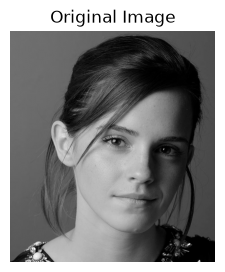

In [233]:
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q1.jpeg",cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(3, 3));plt.imshow(im, cmap="gray");plt.title("Original Image");plt.axis("off");plt.show()

In [234]:
def intensity_transform(im,breakpoints):
    x = breakpoints[:,0]
    y = breakpoints[:,1]
    transformed = np.interp(im, x, y)
    return transformed.astype(np.uint8)

In [235]:
breakpoints=np.array([[0,0],[50,50],[50,100],[150,255],[150,150],[255,255]])
transformed=intensity_transform(im,breakpoints)

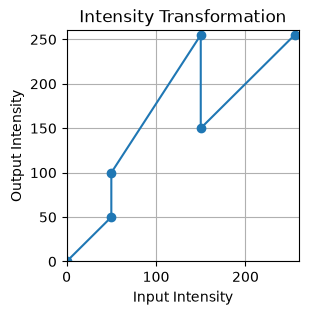

In [236]:
plt.figure(figsize=(3, 3))
plt.plot(breakpoints[:, 0],breakpoints[:, 1],marker="o");plt.xlabel("Input Intensity");plt.ylabel("Output Intensity")
plt.title("Intensity Transformation");plt.xlim(0, 260);plt.ylim(0, 260);plt.grid();plt.show()

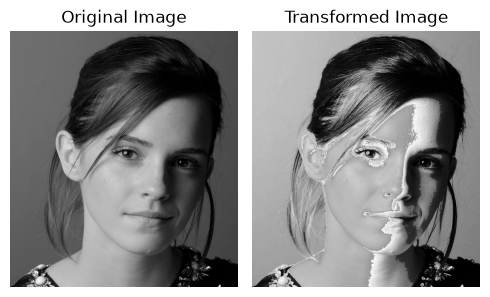

In [237]:
plt.figure(figsize=(5, 3))

plt.subplot(1, 2, 1);plt.imshow(im, cmap="gray", vmin=0, vmax=255);plt.title("Original Image");plt.axis("off")
plt.subplot(1, 2, 2);plt.imshow(transformed, cmap="gray", vmin=0, vmax=255);plt.title("Transformed Image");plt.axis("off")
plt.tight_layout();plt.show()

*Question 2*

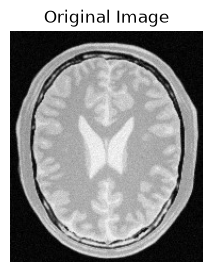

In [238]:
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q2.jpeg",cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(3, 3));plt.imshow(im, cmap="gray");plt.title("Original Image");plt.axis("off");plt.show()

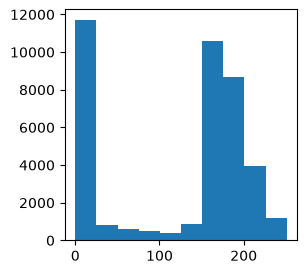

In [239]:
plt.figure(figsize=(3,3));plt.hist(im.ravel());plt.show()

(a)White matter accentuate

In [240]:
breakpoints = np.array([[0, 0],[150, 0],[210, 255],[255, 255]])
transformed =intensity_transform(im,breakpoints)

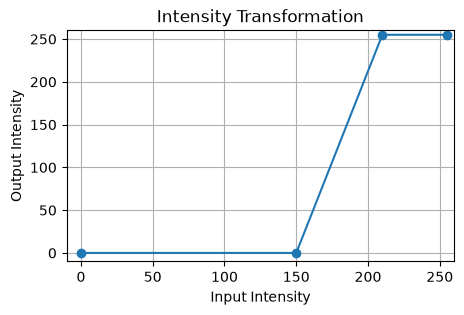

In [241]:
plt.figure(figsize=(5, 3))
plt.plot(breakpoints[:, 0],breakpoints[:, 1],marker="o");plt.xlabel("Input Intensity");plt.ylabel("Output Intensity")
plt.title("Intensity Transformation");plt.xlim(-10, 260);plt.ylim(-10, 260)
plt.grid();plt.show()

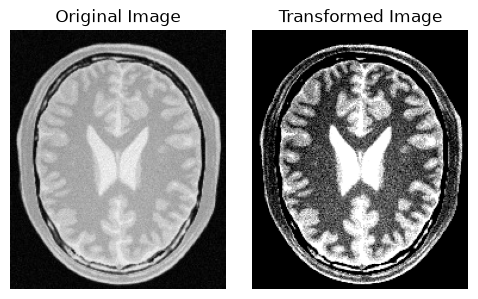

In [242]:
plt.figure(figsize=(5, 3))

plt.subplot(1, 2, 1);plt.imshow(im, cmap="gray", vmin=0, vmax=255);plt.title("Original Image");plt.axis("off")

plt.subplot(1, 2, 2);plt.imshow(transformed, cmap="gray", vmin=0, vmax=255);plt.title("Transformed Image");plt.axis("off")

plt.tight_layout();plt.show()

(b)Gray matter accentuate

In [243]:
breakpoints = np.array([[0, 0],[110, 0],[110, 255],[180, 255],[180,80],[255,0]])
transformed = intensity_transform(im, breakpoints)

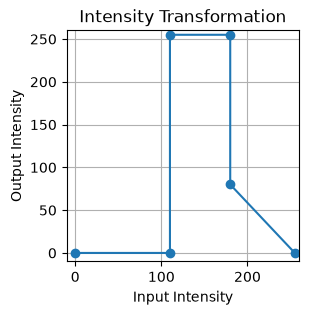

In [244]:
plt.figure(figsize=(3, 3))
plt.plot(breakpoints[:, 0],breakpoints[:, 1],marker="o");plt.xlabel("Input Intensity");plt.ylabel("Output Intensity")
plt.title("Intensity Transformation");plt.xlim(-10, 260);plt.ylim(-10, 260);plt.grid();plt.show()

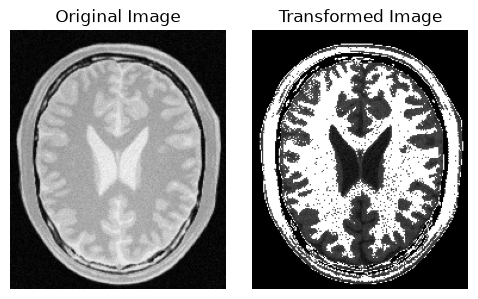

In [245]:
plt.figure(figsize=(5, 3))

plt.subplot(1, 2, 1);plt.imshow(im, cmap="gray", vmin=0, vmax=255);plt.title("Original Image");plt.axis("off")
plt.subplot(1, 2, 2);plt.imshow(transformed, cmap="gray", vmin=0, vmax=255);plt.title("Transformed Image");plt.axis("off")
plt.tight_layout();plt.show()

Question 03

(a) Apply Gamma Correction

In [246]:
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q3.jpeg")
lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)

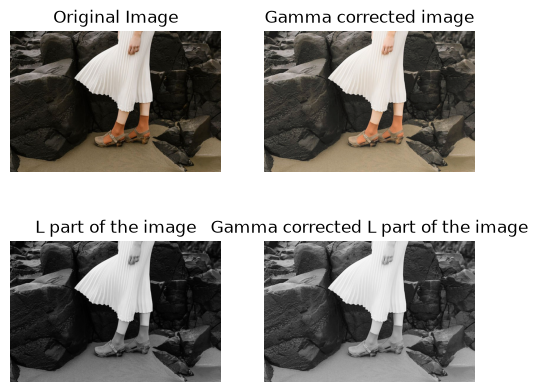

In [247]:
#L part give the idea about how dark or bright the pixel is

l,a,b = cv.split(lab)
l_norm = l/255; gamma = 0.6
l_gamma = np.power(l_norm, gamma); l_gamma = np.uint8(l_gamma*255)
lab_gamma = cv.merge([l_gamma,a,b]); result = cv.cvtColor(lab_gamma, cv.COLOR_LAB2RGB)
im_2=cv.cvtColor(im, cv.COLOR_BGR2RGB)
plt.figure(figsize=(6,5))

plt.subplot(2,2,1);plt.imshow(im_2);plt.title("Original Image");plt.axis("off")
plt.subplot(2,2,2);plt.imshow(result);plt.title("Gamma corrected image");plt.axis("off")
plt.subplot(2,2,3);plt.imshow(l, cmap='gray');plt.title("L part of the image");plt.axis("off")
plt.subplot(2,2,4);plt.imshow(l_gamma, cmap='gray');plt.title("Gamma corrected L part of the image");plt.axis("off");plt.show()

(b) Histogram


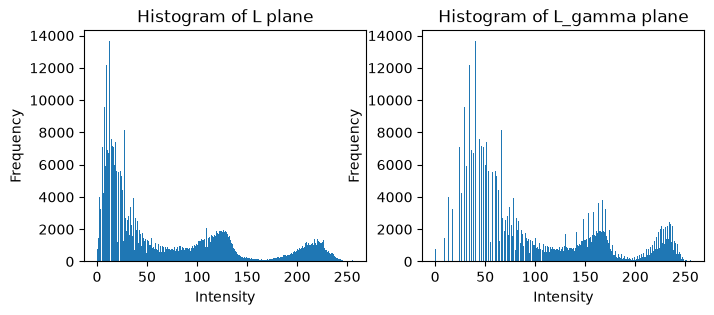

In [248]:
#Histograms of the image

plt.figure(figsize=(8,3))

plt.subplot(1,2,1);plt.hist(l.ravel(), bins=256, range=[0, 256]);plt.xlabel("Intensity");plt.ylabel("Frequency");plt.title("Histogram of L plane")
plt.subplot(1,2,2);plt.hist(l_gamma.ravel(), bins=256, range=[0, 256]);plt.xlabel("Intensity");plt.ylabel("Frequency");plt.title("Histogram of L_gamma plane")
plt.show()

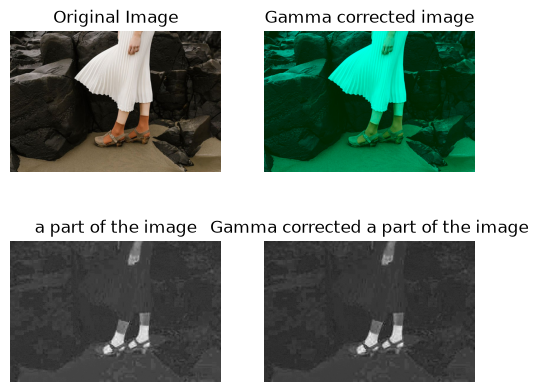

In [249]:
#what happen if we apply gamma correction to the a or b
#lets apply gamma correction to a

l,a,b = cv.split(lab)
a_norm = a/255;gamma = 2
a_gamma = np.power(a_norm, gamma);a_gamma = np.uint8(a_gamma*255)
lab_gamma = cv.merge([l,a_gamma,b]);result = cv.cvtColor(lab_gamma, cv.COLOR_LAB2RGB)
im_2=cv.cvtColor(im, cv.COLOR_BGR2RGB)
plt.figure(figsize=(6,5))

plt.subplot(2,2,1);plt.imshow(im_2);plt.title("Original Image");plt.axis("off")
plt.subplot(2,2,2);plt.imshow(result);plt.title("Gamma corrected image");plt.axis("off")
plt.subplot(2,2,3);plt.imshow(a, cmap='gray');plt.title("a part of the image");plt.axis("off")
plt.subplot(2,2,4);plt.imshow(a_gamma, cmap='gray');plt.title("Gamma corrected a part of the image");plt.axis("off");plt.show()

Question 04


In [250]:
def vibrance_enhanced_pixel(pixel_val, a, sig):
    pixel_val = int(pixel_val)
    k=((pixel_val-128)**2)/(2*(sig**2))
    b=np.exp(-k)
    value = pixel_val + (128*a*b)
    if value > 255:
        output_val=255
    else:
        output_val=value
    return np.uint8(output_val)

(a)Split the image into hue, saturation, and value planes.

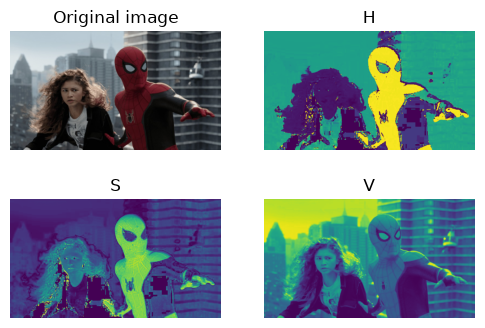

In [251]:
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q4.jpeg")
im_2 = cv.cvtColor(im, cv.COLOR_BGR2RGB)
HSV_im = cv.cvtColor(im, cv.COLOR_BGR2HSV)
H,S,V = cv.split(HSV_im)
plt.figure(figsize=(6,4))

plt.subplot(2,2,1);plt.imshow(im_2);plt.title("Original image");plt.axis("off")
plt.subplot(2,2,2);plt.imshow(H);plt.title("H");plt.axis("off")
plt.subplot(2,2,3);plt.imshow(S);plt.title("S");plt.axis("off")
plt.subplot(2,2,4);plt.imshow(V);plt.title("V");plt.axis("off")
plt.show()

(b) Apply the aforementioned intensity transformation to the saturation plane.

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

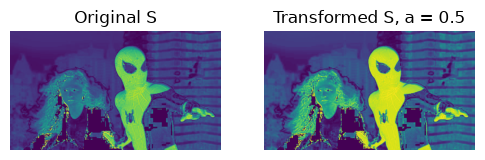

In [252]:
a= 0.5;sig = 70
rows = len(S);column = len(S[0])
transformed_S = S.copy()
for i in range(rows):
    for j in range(column):
        transformed_S[i][j] = vibrance_enhanced_pixel(S[i][j], a, sig)
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1);plt.imshow(S);plt.title("Original S");plt.axis("off")
plt.subplot(1, 2, 2);plt.imshow(transformed_S);plt.title(f"Transformed S, a = {a:.1f}");plt.axis("off")
        

(c) Adjust a to get a visually pleasing output. Report the value of a.

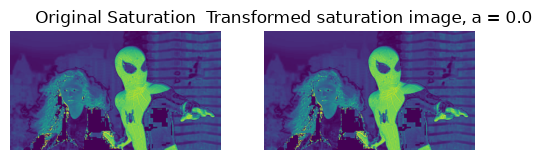

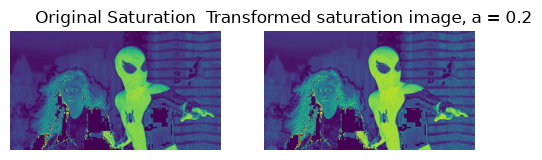

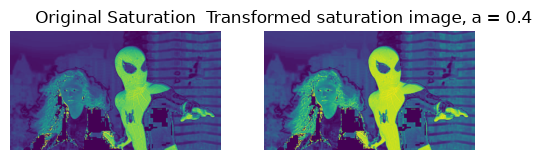

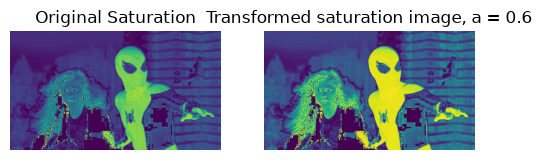

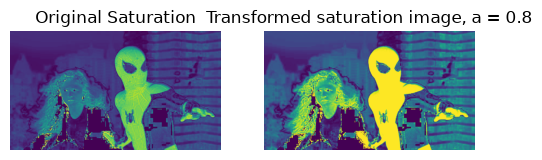

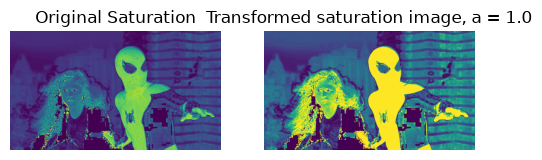

In [253]:
a_array = np.arange(0, 1.2, 0.2)
sig = 70;rows = len(S);column = len(S[0])
for a in a_array:
    transformed_S = S.copy()
    for i in range(rows):
        for j in range(column):
            transformed_S[i][j] = vibrance_enhanced_pixel(S[i][j], a, sig)
    plt.figure(figsize=(6, 4))
    plt.subplot(1, 2, 1);plt.imshow(S);plt.title("Original Saturation");plt.axis("off")
    plt.subplot(1, 2, 2);plt.imshow(transformed_S);plt.title(f"Transformed saturation image, a = {a:.1f}");plt.axis("off")
    plt.show()


For visually pleasing output, the suitable "a" value is 0.8

(d) Recombine the three planes.

In [ ]:
a = 0.8
sig = 70
transformed_S = S.copy()
for i in range(rows):
    for j in range(column):
        transformed_S[i][j] = vibrance_enhanced_pixel(S[i][j], a, sig)
HSV_image = cv.merge([H, transformed_S, V])
Transformed_image = cv.cvtColor(HSV_image, cv.COLOR_HSV2RGB)

(e) Display the original image, vibrance-enhanced image, and the intensity transformation.

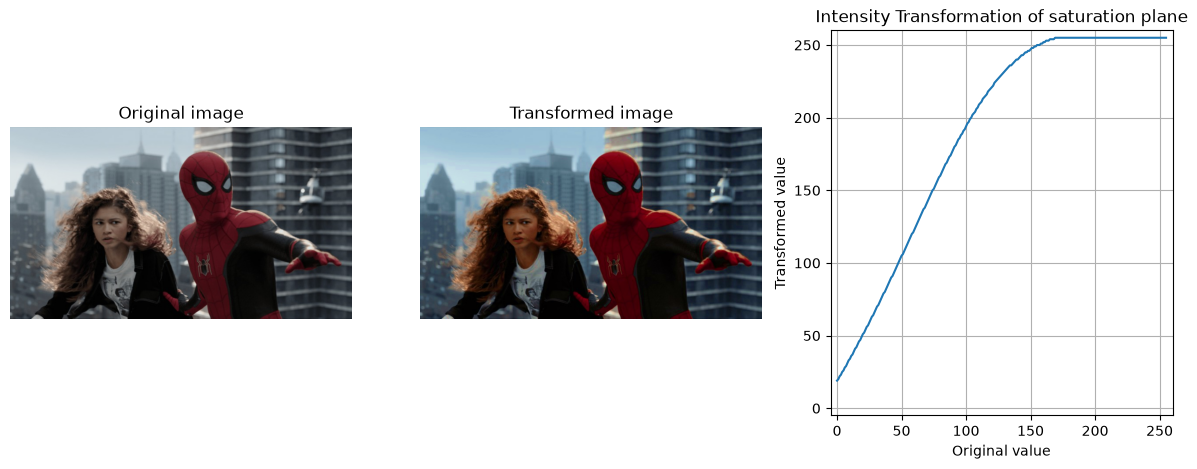

In [254]:
#inteansity transformation
pixel_val = np.arange(0,256,1);transformed_pixels = np.zeros(256);a=0.8;sig=70
for i in range(len(transformed_pixels)):
    transformed_pixels[i] = vibrance_enhanced_pixel(pixel_val[i], a, sig)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
im=cv.cvtColor(im, cv.COLOR_BGR2RGB)
plt.imshow(im);plt.title("Original image");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(Transformed_image);plt.title("Transformed image");plt.axis("off")
plt.subplot(1,3,3);plt.plot(transformed_pixels);plt.title("Intensity Transformation of saturation plane")
plt.xlim((-5,260));plt.ylim((-5,260));plt.xlabel("Original value");plt.ylabel("Transformed value");plt.grid(True)


Question 05

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

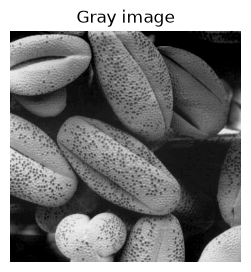

In [255]:
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q5.TIF")
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
plt.figure(figsize=(3,3));plt.imshow(im_gray, cmap="gray");plt.title("Gray image");plt.axis("off")


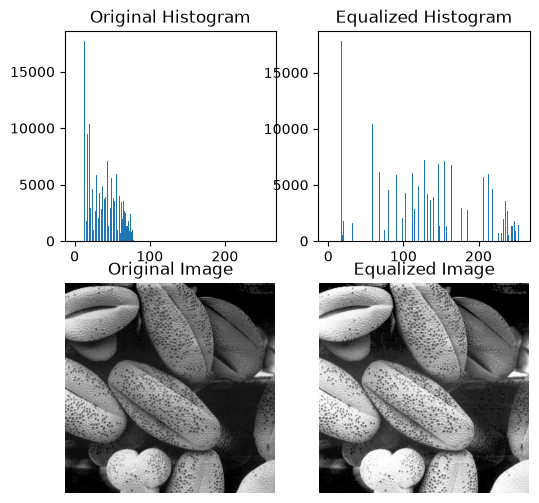

In [256]:
#get original histogram
hist_array = np.zeros(256)
x = np.arange(0, 256, 1)
for row in im_gray:
    for pixel in row:
        hist_array[pixel] = hist_array[pixel] + 1
#histogram Equalizing
pdf = hist_array/im_gray.size
cdf = np.cumsum(pdf)
transform = np.round(255 * cdf).astype(np.uint8)
equalized_im = np.zeros_like(im_gray)
for i in range(im_gray.shape[0]):
    for j in range(im_gray.shape[1]):
        equalized_im[i][j] = transform[im_gray[i][j]]
equalized_hist_array = np.zeros(256)
for row in equalized_im:
    for pixel in row:
        equalized_hist_array[pixel] = equalized_hist_array[pixel] + 1
plt.figure(figsize=(6, 6))
plt.subplot(2,2,1);plt.bar(x,hist_array);plt.title("Original Histogram")
plt.subplot(2,2,2);plt.bar(x,equalized_hist_array);plt.title("Equalized Histogram")
plt.subplot(2, 2, 3);plt.imshow(im_gray, cmap='gray');plt.title("Original Image");plt.axis("off")
plt.subplot(2, 2, 4);plt.imshow(equalized_im, cmap='gray');plt.title("Equalized Image");plt.axis("off")
plt.show()



Question 6

[]

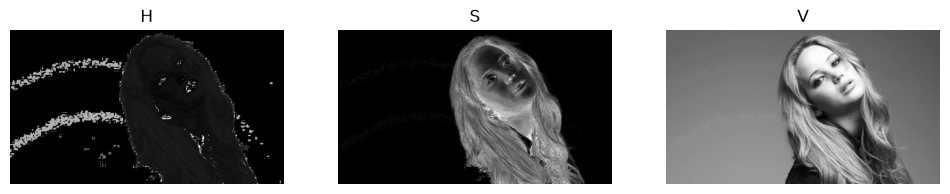

In [257]:
#(a)
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q6.jpeg")
hsv_im= cv.cvtColor(im, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv_im)
plt.figure(figsize=(12,7))
plt.subplot(1,3,1);plt.imshow(H, cmap="gray");plt.title("H");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(S, cmap="gray");plt.title("S");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(V, cmap="gray");plt.title("V");plt.axis("off")
plt.plot()

(b) Saturation plane is good for extract the mask

(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

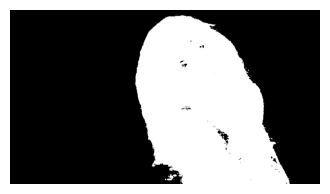

In [258]:
#mask extracting
binary_mask = S.copy()
Threshold = 14
for row_num in range(len(S)):
    for pixel_num in range(len(S[1])):
        if S[row_num][pixel_num] < Threshold:
            binary_mask[row_num][pixel_num] = 0
        else:
            binary_mask[row_num][pixel_num] = 1
binary_image = (binary_mask * 255).astype(np.uint8)
plt.figure(figsize=(4,4))
plt.imshow(binary_image, cmap="gray")
plt.axis("off")


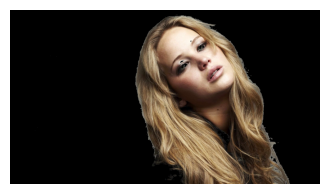

In [259]:
#(c)
foreground = cv.bitwise_and(im, im, mask=binary_image)
plt.figure(figsize=(4,4))
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

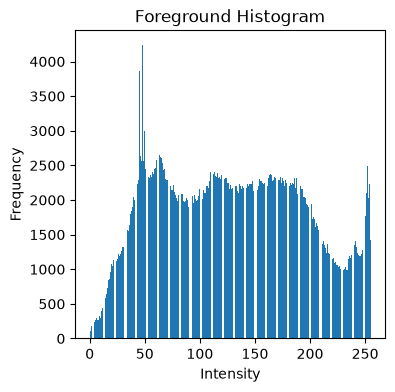

In [260]:
#histogram apply to V channel. otherwise final output will be gray in color

hist_array = np.zeros(256)
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        if binary_image[i][j] == 255:
            hist_array[V[i][j]] += 1
plt.figure(figsize=(4,4));plt.bar(np.arange(256), hist_array);plt.xlabel("Intensity");plt.ylabel("Frequency")
plt.title("Foreground Histogram");plt.show()


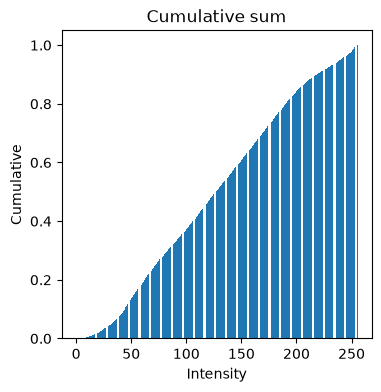

In [261]:
foreground_pixels = np.sum(binary_image == 255)
pdf = hist_array / foreground_pixels
cdf = np.cumsum(pdf)
plt.figure(figsize=(4,4));plt.bar(np.arange(256), cdf);plt.xlabel("Intensity");plt.ylabel("Cumulative")
plt.title("Cumulative sum");plt.show()

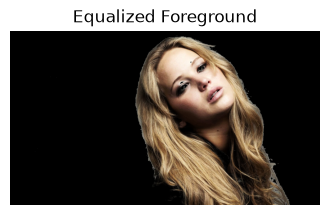

In [262]:
#(e) histogram Equalization
transform = np.round(255 * cdf).astype(np.uint8)
V_equalized = V.copy()
# Equalize only foreground pixels
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        if binary_image[i][j] == 255:
            V_equalized[i][j] = transform[V[i][j]]
equalized_hsv = cv.merge([H, S, V_equalized])
equalized_color = cv.cvtColor(equalized_hsv, cv.COLOR_HSV2BGR)
equalized_foreground = cv.bitwise_and(equalized_color,equalized_color,mask=binary_image)
plt.figure(figsize=(4,4));plt.imshow(cv.cvtColor(equalized_foreground, cv.COLOR_BGR2RGB))
plt.title("Equalized Foreground");plt.axis("off");plt.show()

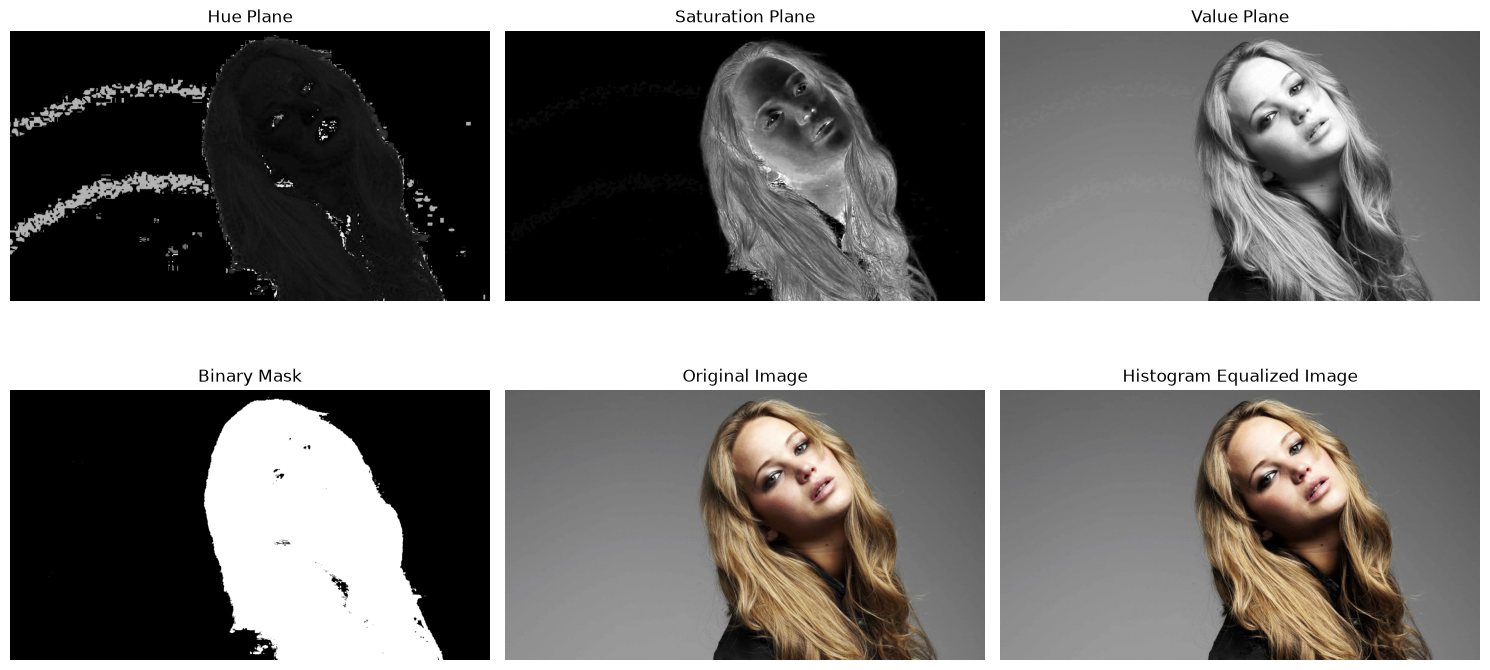

In [263]:
# (f) Extract background and combine with equalized foreground
background_mask = cv.bitwise_not(binary_image)
background = cv.bitwise_and(im,im,mask=background_mask)
result = cv.add(background, equalized_foreground)
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1);plt.imshow(H, cmap="gray");plt.title("Hue Plane");plt.axis("off")
plt.subplot(2, 3, 2);plt.imshow(S, cmap="gray");plt.title("Saturation Plane");plt.axis("off")
plt.subplot(2, 3, 3);plt.imshow(V, cmap="gray");plt.title("Value Plane");plt.axis("off")
plt.subplot(2, 3, 4);plt.imshow(binary_image, cmap="gray");plt.title("Binary Mask");plt.axis("off")
plt.subplot(2, 3, 5);plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB));plt.title("Original Image");plt.axis("off")
plt.subplot(2, 3, 6);plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB));plt.title("Histogram Equalized Image");plt.axis("off")
plt.tight_layout();plt.show()

 Question 07

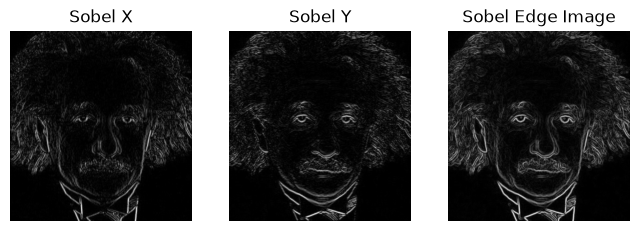

In [264]:
#(a)
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q7.jpeg")
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
sobel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]])
gx = cv.filter2D(gray, cv.CV_64F, sobel_x)
gy = cv.filter2D(gray, cv.CV_64F, sobel_y)
sobel = np.sqrt(gx**2 + gy**2)
sobel = cv.normalize(sobel, None, 0, 255, cv.NORM_MINMAX)
sobel = sobel.astype(np.uint8)
plt.figure(figsize=(8,4))
plt.subplot(1,3,1);plt.imshow(np.abs(gx), cmap="gray");plt.title("Sobel X");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(np.abs(gy), cmap="gray");plt.title("Sobel Y");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(sobel, cmap="gray");plt.title("Sobel Edge Image");plt.axis("off")
plt.show()

In [ ]:
def convolve2D(image, kernal):
    n, m = image.shape
    convolved_mat = np.zeros((n-2, m-2), dtype=float)
    for row in range(1, n-1):
        for pixel in range(1, m-1):
            convolved_mat[row-1][pixel-1] = (
                kernal[0][0] * image[row-1][pixel-1] +
                kernal[0][1] * image[row-1][pixel] +
                kernal[0][2] * image[row-1][pixel+1] +
                kernal[1][0] * image[row][pixel-1] +
                kernal[1][1] * image[row][pixel] +
                kernal[1][2] * image[row][pixel+1] +
                kernal[2][0] * image[row+1][pixel-1] +
                kernal[2][1] * image[row+1][pixel] +
                kernal[2][2] * image[row+1][pixel+1]
            )
    return convolved_mat

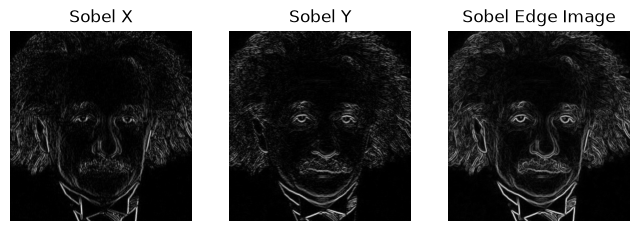

In [265]:
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q7.jpeg")
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
sobel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]])
gx = convolve2D(gray, sobel_x)
gy = convolve2D(gray, sobel_y)
sobel = np.sqrt(gx**2 + gy**2)
sobel = cv.normalize(sobel, None, 0, 255, cv.NORM_MINMAX)
sobel = sobel.astype(np.uint8)
plt.figure(figsize=(8,4))
plt.subplot(1,3,1);plt.imshow(np.abs(gx), cmap="gray");plt.title("Sobel X");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(np.abs(gy), cmap="gray");plt.title("Sobel Y");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(sobel, cmap="gray");plt.title("Sobel Edge Image");plt.axis("off")
plt.show()

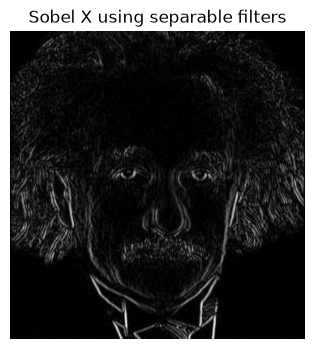

In [266]:
kernel_x = np.array([[1, 0, -1]])
kernel_y = np.array([[1],[2],[1]])
temp = cv.filter2D(gray, cv.CV_64F, kernel_x)
gx = cv.filter2D(temp, cv.CV_64F, kernel_y)
plt.figure(figsize=(4,4));plt.imshow(np.abs(gx), cmap="gray");plt.title("Sobel X using separable filters")
plt.axis("off");plt.show()

Question 8

In [267]:
def zoom(im, factor, method):
    h, w, channel = im.shape
    zoomed_h = int(h * factor)
    zoomed_w = int(w * factor)
    zoomed_im = np.zeros((zoomed_h, zoomed_w, channel), dtype=im.dtype)
    for row in range(zoomed_h):
        src_row = row / factor
        for col in range(zoomed_w):
            src_col = col / factor
            if method == "nearest":
                r = int(round(src_row))
                c = int(round(src_col))
                r = min(r, h-1)
                c = min(c, w-1)
                zoomed_im[row, col] = im[r, c]
            elif method == "bilinear":
                r1 = int(np.floor(src_row))
                c1 = int(np.floor(src_col))
                r2 = min(r1 + 1, h-1)
                c2 = min(c1 + 1, w-1)
                dr = src_row - r1
                dc = src_col - c1
                top = (1-dc) * im[r1, c1] + dc * im[r1, c2]
                bottom = (1-dc) * im[r2, c1] + dc * im[r2, c2]
                value = (1-dr) * top + dr * bottom
                zoomed_im[row, col] = value
    return zoomed_im

In [268]:
def SSD(im1, im2):

    x, y, z = im1.shape
    N = x * y * z
    total = 0
    for i in range(x):
        for j in range(y):
            for k in range(z):
                diff = int(im1[i][j][k]) - int(im2[i][j][k])
                total = total + diff**2
    return float(total / N)

In [269]:
#image 01
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q8_s_1.PNG")
im_large = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q8_l_1.PNG")
nearest_im = zoom(im, 4, "nearest")
bilinear_im = zoom(im, 4, "bilinear")


In [270]:
print("NN_SSD: ", SSD(im_large,nearest_im) )
print("BIL_SSD: ", SSD(im_large,bilinear_im) )

NN_SSD:  255.29569331918725
BIL_SSD:  200.24514017489713


In [271]:
#image 01
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q8_s_2.PNG")
im_large = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q8_l_2.PNG")
nearest_im = zoom(im, 4, "nearest")
bilinear_im = zoom(im, 4, "bilinear")

print("NN_SSD: ", SSD(im_large,nearest_im) )
print("BIL_SSD: ", SSD(im_large,bilinear_im) )

NN_SSD:  64.62937832754629
BIL_SSD:  48.96066550925926


Question 9

In [272]:

#(a)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q9.jpeg")
mask = np.zeros(im.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
h, w = im.shape[:2]
rect = (40, 40, w-80, h-80)
cv.grabCut(im,mask,rect,bgdModel,fgdModel,5,cv.GC_INIT_WITH_RECT)
final_mask = np.where((mask == cv.GC_BGD) | (mask == cv.GC_PR_BGD),0,1).astype("uint8")
foreground = im * final_mask[:, :, np.newaxis]
background_mask = 1 - final_mask
background = im * background_mask[:, :, np.newaxis]

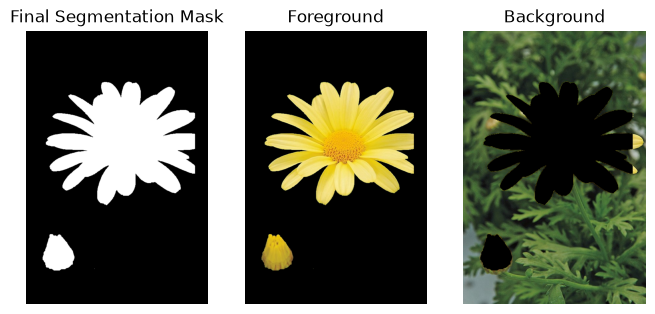

In [273]:
plt.figure(figsize=(8,4))

plt.subplot(1,3,1);plt.imshow(final_mask, cmap="gray");plt.title("Final Segmentation Mask");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB));plt.title("Foreground");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB));plt.title("Background");plt.axis("off")
plt.show()

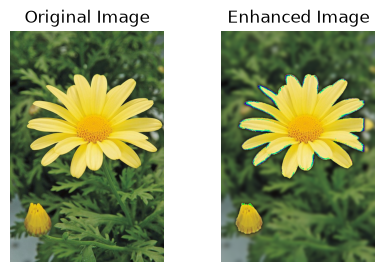

In [274]:
#(b)
background = im * background_mask[:, :, np.newaxis]
blurred_background = cv.GaussianBlur(background, (31,31), 0)
enhanced = foreground + blurred_background
plt.figure(figsize=(5,3))
plt.subplot(1,2,1);plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB));plt.title("Original Image");plt.axis("off")
plt.subplot(1,2,2);plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB));plt.title("Enhanced Image");plt.axis("off")
plt.show()

The dark region appears because, when the foreground flower is removed from the background image, those flower pixels are replaced with black pixels. When Gaussian blur is applied to this background image, the blur averages nearby pixels together. Near the flower boundary, normal background pixels are averaged with the black pixels from the removed flower region, which reduces the intensity and makes that area look darker. This creates the dark halo just outside the edge of the flower. 

This effect can be reduced by first blurring the original image and then applying the background mask, instead of blurring the extracted background that contains black pixels. This prevents the black foreground area from being included in the Gaussian averaging and therefore reduces the dark halo around the flower.

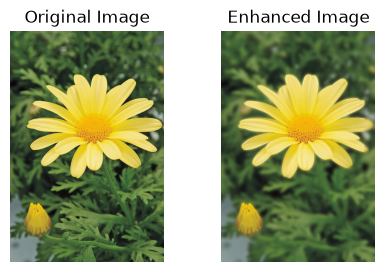

In [275]:
#Blurring without black edges
blurred = cv.GaussianBlur(im, (31,31),5)
blurred_background = blurred * background_mask[:, :, np.newaxis]
enhanced = foreground + blurred_background
plt.figure(figsize=(5,3))
plt.subplot(1,2,1);plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB));plt.title("Original Image");plt.axis("off")
plt.subplot(1,2,2);plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB));plt.title("Enhanced Image");plt.axis("off")
plt.show()

Question 10

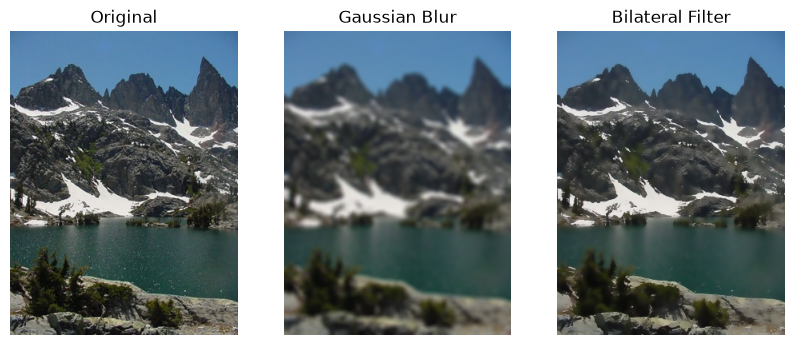

In [276]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread("C:/My Drive/Academics/Computer vision/Assignment/images/images/q10.jpeg")
gaussian = cv.GaussianBlur(im, (9, 9), 3)
bilateral = cv.bilateralFilter(im,d=9,sigmaColor=90,sigmaSpace=90)
plt.figure(figsize=(10,5))
plt.subplot(1,3,1);plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB));plt.title("Original");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB));plt.title("Gaussian Blur");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(cv.cvtColor(bilateral, cv.COLOR_BGR2RGB));plt.title("Bilateral Filter");plt.axis("off")
plt.show()

In [278]:
def bilateral_filter(gray, kernel_size, sigma_s, sigma_r):

    h, w = gray.shape
    pad = kernel_size // 2
    output = np.zeros_like(gray, dtype=np.float64)
    for i in range(pad, h-pad):
        for j in range(pad, w-pad):
            center = float(gray[i,j])
            weighted_sum = 0
            weight_total = 0
            for x in range(-pad, pad+1):
                for y in range(-pad, pad+1):
                    neighbor = float(gray[i+x, j+y])
                    # Spatial distance
                    spatial_weight = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
                    # Intensity difference
                    range_weight = np.exp(-((neighbor-center)**2) / (2 * sigma_r**2))
                    weight = spatial_weight * range_weight
                    weighted_sum += weight * neighbor
                    weight_total += weight
            output[i,j] = weighted_sum / weight_total
    return output.astype(np.uint8)

In [279]:
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
manual_bilateral = bilateral_filter(gray,kernel_size=9,sigma_s=75,sigma_r=75)
opencv_bilateral = cv.bilateralFilter(gray,d=9,sigmaColor=75,sigmaSpace=75)

In [280]:
def MSE(im1, im2):
    im1 = im1.astype(np.float64)
    im2 = im2.astype(np.float64)
    return np.mean((im1 - im2)**2)

In [281]:
error = MSE(opencv_bilateral, manual_bilateral)
print("MSE between OpenCV and manual bilateral filter:", error)

MSE between OpenCV and manual bilateral filter: 502.30043397968603


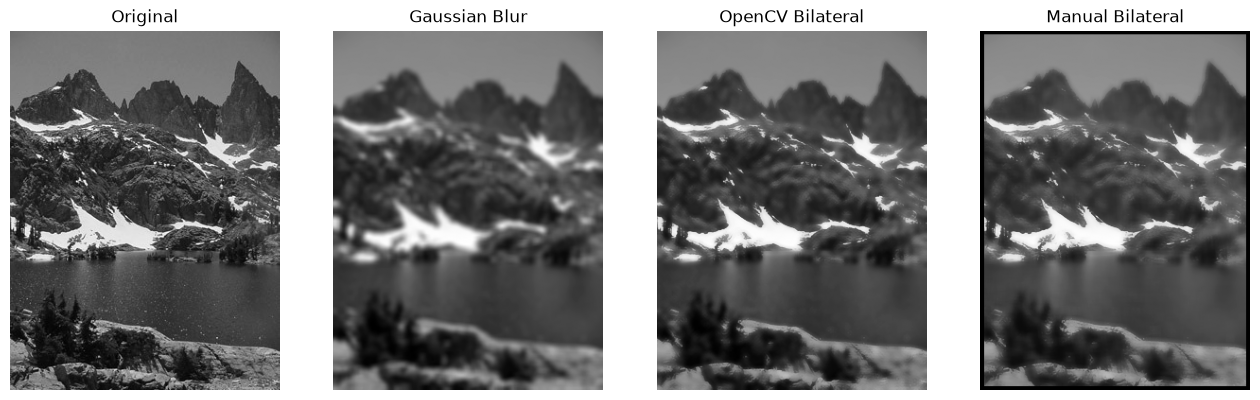

In [282]:
gaussian_gray = cv.GaussianBlur(gray, (9,9), 3)

plt.figure(figsize=(16,5))
plt.subplot(1,4,1);plt.imshow(gray, cmap="gray");plt.title("Original");plt.axis("off")
plt.subplot(1,4,2);plt.imshow(gaussian_gray, cmap="gray");plt.title("Gaussian Blur");plt.axis("off")
plt.subplot(1,4,3);plt.imshow(opencv_bilateral, cmap="gray");plt.title("OpenCV Bilateral");plt.axis("off")
plt.subplot(1,4,4);plt.imshow(manual_bilateral, cmap="gray");plt.title("Manual Bilateral");plt.axis("off")
plt.show()